In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot

import numpy as np

In [2]:
ukesm_1990_2020_forecasts_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks_forecasts/z64_graphcast.zarr').astype(np.float32)
ukesm_2049_forecasts_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative_forecasts/z64_graphcast.zarr', decode_timedelta=True).astype(np.float32)

ukesm_historical_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks/fields.zarr').astype(np.float32)
ukesm_future_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative/fields.zarr').astype(np.float32)


/scratch/slurm_tmpdir/job_3707562/ipykernel_2185423/1269697474.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ukesm_1990_2020_forecasts_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks_forecasts/z64_graphcast.zarr').astype(np.float32)


In [3]:
print(ukesm_1990_2020_forecasts_equiangular_wp_cons_z64)
print(ukesm_historical_truth_equiangular_wp_cons)

<xarray.Dataset> Size: 186GB
Dimensions:                      (time: 2892, prediction_timedelta: 40,
                                  longitude: 128, latitude: 64, level: 6)
Coordinates:
  * latitude                     (latitude) float64 512B -90.0 -87.14 ... 90.0
  * level                        (level) float32 24B 925.0 850.0 ... 300.0 200.0
  * longitude                    (longitude) float64 1kB 0.0 2.812 ... 357.2
  * prediction_timedelta         (prediction_timedelta) timedelta64[ns] 320B ...
  * time                         (time) object 23kB 2011-01-01 06:00:00 ... 2...
Data variables: (12/14)
    10m_wind_speed               (time, prediction_timedelta, longitude, latitude) float32 4GB dask.array<chunksize=(8, 10, 64, 32), meta=np.ndarray>
    geopotential_500             (time, prediction_timedelta, longitude, latitude) float32 4GB dask.array<chunksize=(8, 10, 64, 32), meta=np.ndarray>
    mean_sea_level_pressure      (time, prediction_timedelta, longitude, latitude) float3

Select one variable:

In [6]:
display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES_UKESM[1]
truth_historical = ukesm_historical_truth_equiangular_wp_cons[variable].sel(time=slice("1985", "2010"))
if (plevel):
    truth_historical = truth_historical.sel(level=plevel)
truth_historical = plot.get_masked_ukesm_data(truth_historical, plevel=plevel)
truth_historical=truth_historical.where(truth_historical>0)
max_value = truth_historical.max().values
min_value = truth_historical.min().values
print(min_value)

221.86797


In [8]:
import pickle
load=False
min_max_values = []
save_name = 'min_max_values_ukesm'
if not load:
    for i in range(len(plot.KEY_VARIABLES_UKESM)):
        display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES_UKESM[i]
        truth_historical = ukesm_historical_truth_equiangular_wp_cons[variable].sel(time=slice("1985", "2010"))
        if (plevel):
            truth_historical = truth_historical.sel(level=plevel)
            if plevel>500:
                truth_historical = plot.get_masked_ukesm_data(truth_historical, plevel=plevel)
        max_value = truth_historical.max().values
        min_value = truth_historical.min().values
        print(max_value)
        min_max_values.append((min_value, max_value))
    # Save
    with open(f"{save_name}.pkl", "wb") as f:
        pickle.dump(min_max_values, f)
else:
    with open(f"{save_name}.pkl", "rb") as f:
        min_max_values = pickle.load(f)
    print(min_max_values)

6023.9067
315.26984
0.014657179
323.84357
46.59402
55.128834
115.44497
0.000398456


In [7]:
exceeding = []
for i in range(len(plot.KEY_VARIABLES_UKESM)):
    display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES_UKESM[i]
    truth_future = ukesm_future_truth_equiangular_wp_cons[variable]
    if (plevel):
        truth_future = truth_future.sel(level=plevel)
    mult=1
    if variable == 'geopotential_500':
        mult=plot.UKESM_GEOPOT_CONST
    elif variable == 'total_precipitation_6hr':
        mult= plot.UKESM_PRECIP_CONST
    
    truth_future = truth_future.compute()
    
    (minv, maxv) = min_max_values[i]
    # relative = 'humidity' in variable
    relative = False
    if relative:
        truth_exceeding_positive = (truth_future.where(truth_future > maxv).max(dim='time') / maxv) * 100.0 - 100
        maxplot = truth_exceeding_positive.max()
        plot.plot_single_plot(truth_exceeding_positive.T, f'UKESM {display_name},\nMaximum Relative Extrapolation (2097-2100) compared to Training',
                              f'Relative Extrapolation [%]', (0,maxplot), 'autumn_r',
                              "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/plots/",
                              f'max_extrapolation_{variable}_ukesm')
    else:
        print(maxv)
        truth_future = truth_future-maxv
        truth_exceeding_positive = truth_future.where(truth_future > 0).max(dim='time')*mult
        maxplot = truth_exceeding_positive.max()
        print(maxplot)
        plot.plot_single_plot(truth_exceeding_positive.T, f'UKESM {display_name},\nMaximum Absolute Extrapolation (2097-2100) compared to Training',
                              f'Absolute Extrapolation [{unit}]', (0,maxplot), 'autumn_r',
                              "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/plots/",
                              f'max_extrapolation_{variable}_ukesm',figsize=(8, 6))

6023.9067
<xarray.DataArray 'geopotential_500' ()> Size: 8B
array(1399.27197266)


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


315.26984
<xarray.DataArray 'temperature' ()> Size: 8B
array(7.6569519)
Coordinates:
    level    float32 4B 850.0


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


0.014657179
<xarray.DataArray 'specific_humidity' ()> Size: 8B
array(0.00497333)
Coordinates:
    level    float32 4B 700.0


...

/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


115.44497
<xarray.DataArray 'total_precipitation_6hr' ()> Size: 8B
array(0.06713399)


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


0.000398456
<xarray.DataArray 'relative_vorticity' ()> Size: 8B
array(2.28444114e-05)
Coordinates:
    level    float32 4B 500.0


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


In [12]:
mask_dict = {}
for i in range(len(plot.KEY_VARIABLES_UKESM)):
    display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES_UKESM[i]
    truth_future = ukesm_future_truth_equiangular_wp_cons[variable]
    if (plevel):
        truth_future = truth_future.sel(level=plevel)
        
    truth_future = truth_future.compute()
    
    (minv, maxv) = min_max_values[i]
    
    print(maxv)
    truth_future = (truth_future-maxv).max(dim='time')
    mask = (truth_future > 0).astype(int)
    if (plevel):
        mask = mask.drop_vars('level')

    # Add this mask to our dictionary, using the variable name
    mask_dict[variable] = mask

# Combine all masks into one dataset
masks_dataset = xr.Dataset(mask_dict)

masks_dataset

6023.9067
315.26984
0.014657179
323.84357
46.59402
55.128834
115.44497
0.000398456


<xarray.Dataset> Size: 526kB
Dimensions:                  (latitude: 64, longitude: 128)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
Data variables:
    geopotential_500         (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    temperature              (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    specific_humidity        (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    surface_temperature      (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    u_component_of_wind      (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    v_component_of_wind      (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    total_precipitation_6hr  (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0
    relative_vorticity       (longitude, latitude) int64 66kB 0 0 0 0 ... 0 0 0

In [15]:
masks_dataset.to_zarr('/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/extrapolation_future.zarr')

/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


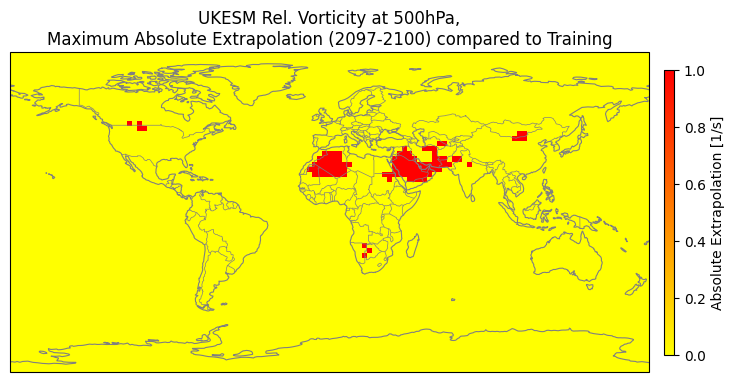

In [14]:
plot.plot_single_plot(masks_dataset['temperature'].T, f'UKESM {display_name},\nMaximum Absolute Extrapolation (2097-2100) compared to Training',
                              f'Absolute Extrapolation [{unit}]', None, 'autumn_r',
                              None,
                              None, show=True)

In [23]:
mask = xr.open_dataset(
        "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/valid_masks.zarr"
    )["all_combined"]
exceeding = []
total=[]
load=False
if not load:
    for i in range(len(plot.KEY_VARIABLES_UKESM)):
        display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES_UKESM[i]
        truth_future = ukesm_future_truth_equiangular_wp_cons[variable]
        # print(truth_future)
        total_vals = len(truth_future.time.values) * len(truth_future.latitude.values) * len(truth_future.longitude.values)
        if (plevel):
            
            truth_future = truth_future.sel(level=plevel)
            if plevel>500:
                total_vals = len(truth_future.time.values) * mask.sel(level=plevel).sum().values
                truth_future = plot.get_masked_ukesm_data(truth_future, plevel=plevel)
        truth_future = truth_future.compute()
        print(f'Total vals for {display_name}: {total_vals}')
        total.append(total_vals)
        (minv, maxv) = min_max_values[i]
        truth_exceeding_positive = truth_future.where(truth_future > maxv, drop=True)
        truth_exceeding_negative = truth_future.where(truth_future < minv, drop=True)
        exceeding.append({'positive': truth_exceeding_positive, 'negative': truth_exceeding_negative})
    
    # Save to file
    with open("exceeding_ukesm.pkl", "wb") as f:
        pickle.dump(exceeding, f)
else:
    with open("exceeding_ukesm.pkl", "rb") as f:
        exceeding = pickle.load(f)
    

Total vals for Geopotential at 500hPa: 47185920
Total vals for Temperature at 850hPa: 39928320
Total vals for Specific Humidity at 700hPa: 43194240
Total vals for 1.5m Temperature: 47185920
Total vals for U-Component of Wind at 850hPa: 39928320
Total vals for V-Component of Wind at 850hPa: 39928320
Total vals for Total Precipitation: 47185920
Total vals for Rel. Vorticity at 500hPa: 47185920


In [ ]:
# for i in range(len(plot.KEY_VARIABLES_UKESM)-1, len(plot.KEY_VARIABLES_UKESM)):
#     display_name, unit, variable, plevel = plot.KEY_VARIABLES_UKESM[i]
#     exceeding[i]['positive_list'] = []
#     exceeding[i]['negative_list'] = []
#     ds_pos = exceeding[i]['positive']
#     for t in ds_pos.time:
#         data_t = ds_pos.sel(time=t)
#         for lat in data_t.latitude:
#             for lon in data_t.longitude:
#                 data_val = data_t.sel(latitude=lat, longitude=lon).values
#                 if not str(data_val) == 'nan':
#                     exceeding[i]['positive_list'].append({'time':t.values, 'lat':lat.values,'lon':lon.values, 'val':data_val})
#     print(f'Eval for var {display_name}')
#     num_pos_exceed = len(exceeding[i]["positive_list"])
#     print(f'Exceeding positive: {num_pos_exceed}')
#     if num_pos_exceed > 0:
#         print(f'Max exceedance: +{max([x["val"] for x in exceeding[i]["positive_list"]]) - min_max_values[i][1]:.5f}{unit}')
        
#     ds_neg = exceeding[i]['negative']
#     for t in ds_neg.time:
#         data_t = ds_neg.sel(time=t)
#         for lat in data_t.latitude:
#             for lon in data_t.longitude:
#                 data_val = data_t.sel(latitude=lat, longitude=lon).values
#                 if not str(data_val) == 'nan':
#                     exceeding[i]['negative_list'].append({'time':t.values, 'lat':lat.values,'lon':lon.values, 'val':data_val})

#     num_neg_exceed = len(exceeding[i]["negative_list"])
#     print(f'Exceeding negative: {num_neg_exceed}')
#     if num_neg_exceed > 0:
#         print(f'Min exceedance: {min([x["val"] for x in exceeding[i]["negative_list"]]) - min_max_values[i][0]:.2f}{unit}')
#     print('#'*20)
#     print('')

In [25]:
import numpy as np
import pandas as pd
from tqdm import tqdm

for i in range(len(plot.KEY_VARIABLES_UKESM)):
    display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES_UKESM[i]
    exceeding[i]['positive_list'] = []
    exceeding[i]['negative_list'] = []

    # --- Handle positive dataset ---
    ds_pos = exceeding[i]['positive']
    data_pos = ds_pos.values  # shape: (time, lon, lat)
    times = ds_pos.time.values
    lats = ds_pos.latitude.values
    lons = ds_pos.longitude.values

    valid_mask = ~np.isnan(data_pos)  # shape (T, L, M)

    # Mask out any lat/lon that are not *fully valid* at that timestamp
    for t_i, valid_t in tqdm(enumerate(valid_mask)):

        # Apply mask to data
        vals = data_pos[t_i][valid_t]
        if vals.size == 0:
            continue

        lon_idx, lat_idx = np.where(valid_t)
        t_vals = t_val = times[t_i]

        # Vectorized append
        exceeding[i]['positive_list'].extend([
            {'time': t_val, 'lon': lons[lo], 'lat': lats[la], 'val': v}
            for la, lo, v in zip(lat_idx, lon_idx, vals)
        ])

    print(f'Eval for var {display_name}')
    num_pos_exceed = len(exceeding[i]['positive_list'])
    print(f'Exceeding positive: {num_pos_exceed} ({num_pos_exceed/total[0]}%)')
    if num_pos_exceed > 0:
        vals = [x['val'] for x in exceeding[i]['positive_list']]
        max_exceed = max(vals) - min_max_values[i][1]
        if 'precip' in variable:
            max_exceed*=plot.UKESM_PRECIP_CONST
        print(f'Max exceedance: +{max_exceed:.5f}{unit}')


5748it [00:04, 1328.62it/s]


Eval for var Geopotential at 500hPa
Exceeding positive: 3873418 (0.0820884280734592%)
Max exceedance: +142.68604m²/s²


814it [00:00, 23825.12it/s]


Eval for var Temperature at 850hPa
Exceeding positive: 6180 (0.00013097127278645834%)
Max exceedance: +7.65695K


3650it [00:00, 56773.74it/s]


...

Eval for var V-Component of Wind at 850hPa
Exceeding positive: 0 (0.0%)


22it [00:00, 151022.40it/s]


Eval for var Total Precipitation
Exceeding positive: 22 (4.662407769097222e-07%)
Max exceedance: +0.06713m


1it [00:00, 22550.02it/s]

Eval for var Rel. Vorticity at 500hPa
Exceeding positive: 1 (2.1192762586805556e-08%)
Max exceedance: +0.000021/s


In [22]:
import numpy as np
import pandas as pd

for i, (display_name, unit, variable, plevel,_) in enumerate(plot.KEY_VARIABLES_UKESM):

    # --- Handle negative dataset (same logic) ---
    ds_neg = exceeding[i]['negative']
    data_neg = ds_neg.values
    valid_mask = ~np.isnan(data_neg)

    for t_i, valid_t in tqdm(enumerate(valid_mask)):
        vals = data_neg[t_i][valid_t]
        if vals.size == 0:
            continue
        lat_idx, lon_idx = np.where(valid_t)
        t_vals = t_val = times[t_i]
        exceeding[i]['negative_list'].extend([
            {'time': t_val, 'lon': lons[lo], 'lat': lats[la], 'val': v}
            for la, lo, v in zip(lat_idx, lon_idx, vals)
        ])
    print(f'Eval for var {display_name}')
    num_neg_exceed = len(exceeding[i]['negative_list'])
    print(f'Exceeding negative: {num_neg_exceed}')
    if num_neg_exceed > 0:
        vals = [x['val'] for x in exceeding[i]['negative_list']]
        min_exceed = min(vals) - min_max_values[i][0]
        print(f'Min exceedance: {min_exceed:.2f}{unit}')
    print('#' * 20, '\n')

0it [00:00, ?it/s]


Eval for var Geopotential at 500hPa
Exceeding negative: 0
#################### 



0it [00:00, ?it/s]


Eval for var Temperature at 850hPa
Exceeding negative: 0
#################### 



0it [00:00, ?it/s]


...

Eval for var 1.5m Temperature
Exceeding negative: 0
#################### 



0it [00:00, ?it/s]


Eval for var U-Component of Wind at 850hPa
Exceeding negative: 0
#################### 



0it [00:00, ?it/s]


IndexError: index 1 is out of bounds for axis 0 with size 1

In [9]:
# for i in range(len(plot.KEY_VARIABLES_UKESM)):
#     display_name, unit, variable, plevel = plot.KEY_VARIABLES_UKESM[i]
#     print(f'Eval for var {display_name}')
#     num_pos_exceed = len(exceeding[i]["positive_list"])
#     print(f'Exceeding positive: {num_pos_exceed}')
#     if num_pos_exceed > 0:
#         print(f'Max exceedance: +{max([x["val"] for x in exceeding[i]["positive_list"]]) - min_max_values[i][1]:.5f}{unit}')
#     num_neg_exceed = len(exceeding[i]["negative_list"])
#     print(f'Exceeding negative: {num_neg_exceed}')
#     if num_neg_exceed > 0:
#         print(f'Min exceedance: {min([x["val"] for x in exceeding[i]["negative_list"]]) - min_max_values[i][0]:.2f}{unit}')
#     print('#'*20)
#     print('')

In [ ]:
# i =0
# points = 0
# diffs = []
# for t in truth_exceeding_positive.time:
#     data_t = truth_exceeding_positive.sel(time=t)
#     # Plot map
#     plt.figure(figsize=(8, 6))
#     ax = plt.axes(projection=ccrs.PlateCarree())
#     ax.set_global()


#     # Add map features
#     ax.add_feature(cfeature.LAND, facecolor="lightgray")
#     ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
#     ax.add_feature(cfeature.BORDERS, linestyle=":")
#     ax.add_feature(cfeature.COASTLINE)

#     for lat in data_t.latitude:
#         for lon in data_t.longitude:
#             data_val = data_t.sel(latitude=lat, longitude=lon).values
#             if not str(data_val) == 'nan':
#                 points = points + 1
#                 diff = data_val-max_value
#                 diffs.append(diff)
#                 ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label='+' + str(diff))
#                 #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

#     ax.set_title(str(t.values)[:13] + f' - {variable}', fontsize=14)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/exceeding_values_2049/positive/{variable}_{i}", dpi=400, bbox_inches='tight',)
#     i = i+1

In [10]:
def get_temporal_index_in_dataset(timestamp, ds):
    # Suppose your timestamp is
    target_time = timestamp
    
    # get the index object from the DataArray
    time_index = ds.get_index("time")
    
    # find the integer position
    idx = time_index.get_loc(target_time)
    return idx

def get_true_data_matching_forecast_timestamps(ds_forecast, ds_truth, prediction_steps):
    '''
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    '''
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps + 1
    idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth) + prediction_steps + 1
    new_forecast = ds_forecast.copy().isel(prediction_timedelta=prediction_steps)
    new_truth = ds_truth.isel(time=slice(idx_truth_first, idx_truth_last + 1)).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_forecast, new_truth

In [19]:
# def get_temporal_index_in_dataset(timestamp, ds):
#     # Suppose your timestamp is
#     target_time = timestamp
    
#     # get the index object from the DataArray
#     time_index = ds.get_index("time")
    
#     # find the integer position
#     idx = time_index.get_loc(target_time)
#     return idx

# def get_true_data_matching_forecast_timestamps(ds_forecast, ds_truth, prediction_steps):
#     '''
#     prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
#     '''
#     first_timestamp_forecast = ds_forecast.time[0].values
#     last_timestamp_forecast = ds_forecast.time[-1].values
#     idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps + 1
#     idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth)
#     return ds_truth.isel(time=slice(idx_truth_first, idx_truth_last))

SyntaxError: incomplete input (1924929633.py, line 16)

In [ ]:
# # for i in range(len(plot.KEY_VARIABLES)):
# i = 0
# display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
# current_ds_forecast = ukesm_2049_forecasts_equiangular_wp_cons_z64[variable]
# current_ds_truth = ukesm_future_truth_equiangular_wp_cons[variable]
# if plevel:
#     current_ds_forecast = current_ds_forecast.sel(level=plevel)
#     current_ds_truth = current_ds_truth.sel(level=plevel)
# new_forecast, new_truth = get_true_data_matching_forecast_timestamps(current_ds_forecast, current_ds_truth, 0)
# print(new_forecast.isel(time=0).time)
# print(new_truth.isel(time=0).time)

<xarray.DataArray 'time' ()> Size: 8B
array('2046-01-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level                 int64 8B 500
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000006
    time                  datetime64[ns] 8B 2046-01-01T12:00:00
<xarray.DataArray 'time' ()> Size: 8B
array('2046-01-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level    int64 8B 500
    time     datetime64[ns] 8B 2046-01-01T12:00:00


In [23]:
# print(f"{points} points exceeding for {variable}")
# print(str(max(diffs))+unit)

NameError: name 'points' is not defined

In [25]:
# truth_future_0_12 = truth_future.sel(time=truth_future.time.dt.hour.isin([0, 12]))
# truth_future_6_18 = truth_future.sel(time=truth_future.time.dt.hour.isin([6, 18]))

In [29]:
# i =0
# points = 0
# for t in truth_exceeding_negative.time:
#     data_t = truth_exceeding_negative.sel(time=t)
#     # Plot map
#     plt.figure(figsize=(8, 6))
#     ax = plt.axes(projection=ccrs.PlateCarree())
#     ax.set_global()


#     # Add map features
#     ax.add_feature(cfeature.LAND, facecolor="lightgray")
#     ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
#     ax.add_feature(cfeature.BORDERS, linestyle=":")
#     ax.add_feature(cfeature.COASTLINE)

#     for lat in data_t.latitude:
#         for lon in data_t.longitude:
#             data_val = data_t.sel(latitude=lat, longitude=lon).values
#             if not str(data_val) == 'nan':
#                 points = points + 1
#                 ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label='-' + str(abs(min_value) - abs(data_val)))
#                 #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

#     ax.set_title(str(t.values)[:13] + f' - {variable}', fontsize=14)
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/exceeding_values_2049/negative/{variable}_{i}", dpi=400)
#     i = i+1

In [30]:
# print(f"{points} points exceeding negative for {variable}")

0 points exceeding negative for 2m_temperature


In [23]:
# # Suppose your timestamp is
# target_time = truth_exceeding_positive.time[0].values

# # get the index object from the DataArray
# time_index = truth_future.get_index("time")
# print(time_index)


# # find the integer position
# print(target_time)
# idx = time_index.get_loc(target_time)
# print(idx)
# print(forecast_future.get_index("time")[idx])

DatetimeIndex(['2049-01-01 00:00:00', '2049-01-01 12:00:00',
               '2049-01-02 00:00:00', '2049-01-02 12:00:00',
               '2049-01-03 00:00:00', '2049-01-03 12:00:00',
               '2049-01-04 00:00:00', '2049-01-04 12:00:00',
               '2049-01-05 00:00:00', '2049-01-05 12:00:00',
               ...
               '2049-12-27 00:00:00', '2049-12-27 12:00:00',
               '2049-12-28 00:00:00', '2049-12-28 12:00:00',
               '2049-12-29 00:00:00', '2049-12-29 12:00:00',
               '2049-12-30 00:00:00', '2049-12-30 12:00:00',
               '2049-12-31 00:00:00', '2049-12-31 12:00:00'],
              dtype='datetime64[ns]', name='time', length=730, freq=None)
2049-07-11T12:00:00.000000000
383
2049-07-11 18:00:00


In [ ]:
# idx = ukesm_future_truth_equiangular_wp_cons.get_index("time").get_loc(target_time)
# print(ukesm_future_truth_equiangular_wp_cons[variable].sel(level=plevel).isel(time=slice(idx, idx+40)))

<xarray.DataArray 'temperature' (time: 40, longitude: 128, latitude: 64)> Size: 1MB
dask.array<getitem, shape=(40, 128, 64), dtype=float32, chunksize=(34, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      int64 8B 850
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 320B 2049-07-11T12:00:00 ... 2049-07-21T...


In [51]:
# print(forecast_future.time[0])

<xarray.DataArray 'time' ()> Size: 8B
array('2049-01-01T06:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level    int64 8B 850
    time     datetime64[ns] 8B 2049-01-01T06:00:00


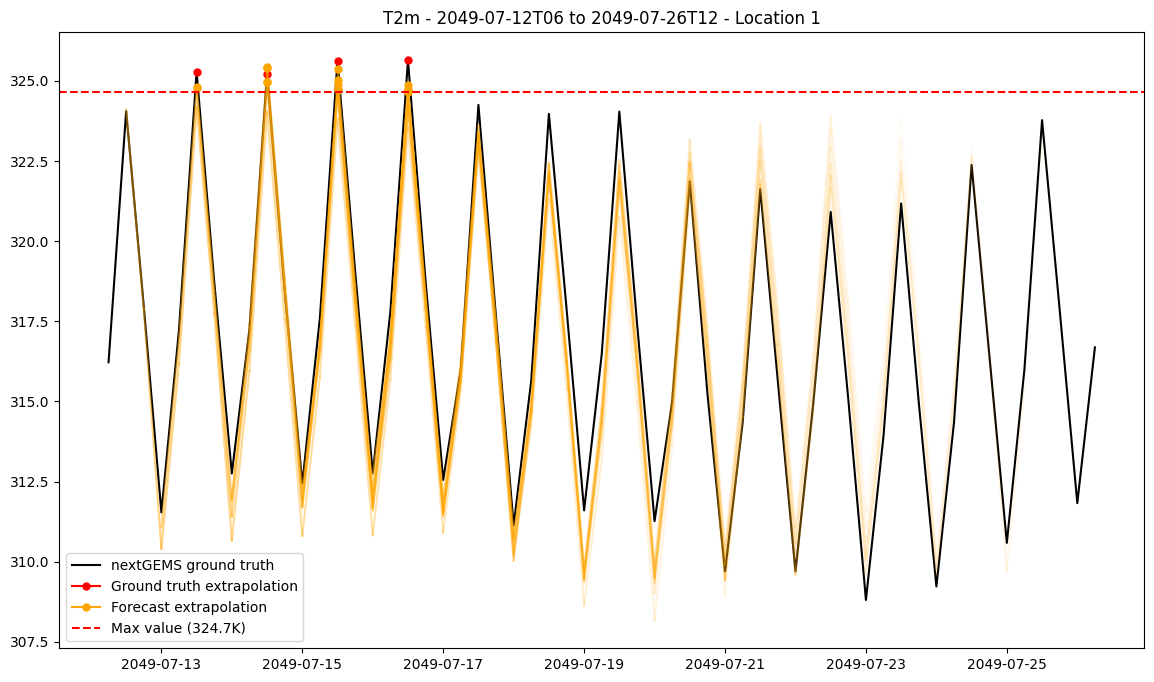

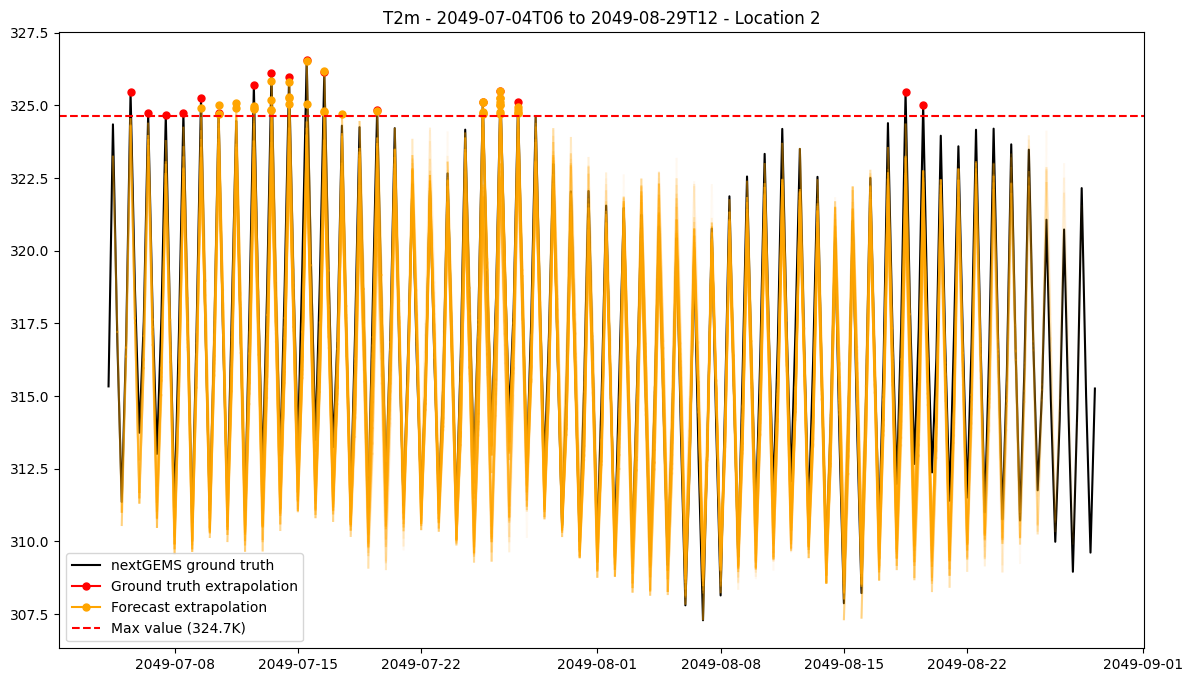

In [ ]:
# true_data_full_time = ukesm_future_truth_equiangular_wp_cons.get_index("time")
# true_data_time = truth_future.get_index("time")
# alpha_base=0.5
# locs = []
# lon=truth_exceeding_positive.longitude.values[0]
# lat=truth_exceeding_positive.latitude.values[0]
# j=0
# for lon in truth_exceeding_positive.longitude.values:
#     for lat in truth_exceeding_positive.latitude.values:
        
        
#         not_nan_times = []
#         for t in truth_exceeding_positive.time.values:
#             data_val = truth_exceeding_positive.sel(latitude=lat, longitude=lon, time=t).values
#             if not str(data_val) == 'nan':
#                 not_nan_times.append(t)
#         if len(not_nan_times) == 0:
#             continue
#         idx_first = true_data_full_time.get_loc(not_nan_times[0])
#         idx_last = true_data_full_time.get_loc(not_nan_times[-1])
#         try:
#             forecast_idx = truth_future_6_18.get_index('time').get_loc(truth_future.time.isel(time=idx_first-5).values)
#             offset=1
#         except Exception:
#             forecast_idx = truth_future_6_18.get_index('time').get_loc(truth_future.time.isel(time=idx_first-4).values)
#             offset=2
#         j = j+1
#         locs.append((lon,lat))
#         plt.figure(figsize=(14, 8))
#         plt.title(f'{display_name} - {str(ukesm_future_truth_equiangular_wp_cons.time.values[idx_first-5])[:13]} to {str(ukesm_future_truth_equiangular_wp_cons.time.values[idx_last+40])[:13]} - Location {j}')
#         #plt.plot(nextgems_2049_truth_equiangular_wp_cons.time.values[idx_first-5 : idx_last+40], nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat).isel(time=slice(idx_first-5, idx_last+40)), color='black', label='nextGEMS ground truth')
#         plt.plot(ukesm_future_truth_equiangular_wp_cons.time.values[idx_first-5 : idx_last+40], ukesm_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat).isel(time=slice(idx_first-5, idx_last+40)), color='black', label='nextGEMS ground truth')
#         first_truth=True
#         for t in not_nan_times:
#             if first_truth:
#                 #plt.plot(t, nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5, label='Ground truth extrapolation')
#                 plt.plot(t, ukesm_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5, label='Ground truth extrapolation')
#                 first_truth=False
#             else:
#                 #plt.plot(t, nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5)
#                 plt.plot(t, ukesm_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5)

#         forecast_future_slice = forecast_future.sel(longitude=lon, latitude=lat).isel(time=slice(forecast_idx, forecast_idx+2+ int((idx_last-idx_first)/2)))

#         first_model=True
#         first_forecast=True
#         for t in forecast_future_slice.time:
#             time_idx = true_data_time.get_loc(t.values)
#             if first_forecast:
#                 times = truth_future.time[time_idx+1: time_idx+41]
#                 values = forecast_future_slice.sel(time=t)
#                 n = len(times)

#                 for i in range(n):
#                     plt.plot(
#                         times[i:i+2],  # short segment
#                         values[i:i+2],
#                         color="orange",
#                         alpha=alpha_base - (i / n)*alpha_base,   # alpha decays
#                     )
#                 #plt.plot(truth_future.time[time_idx+1: time_idx+41], forecast_future_slice.sel(time=t), color="orange", alpha=0.2, label='Forecast')
#                 first_forecast=False
#             else:
#                 #plt.plot(truth_future.time[time_idx+1: time_idx+41], forecast_future_slice.sel(time=t), color="orange", alpha=0.2)
#                 times = truth_future.time[time_idx+1: time_idx+41]
#                 values = forecast_future_slice.sel(time=t)
#                 n = len(times)

#                 for i in range(n):
#                     plt.plot(
#                         times[i:i+2],  # short segment
#                         values[i:i+2],
#                         color="orange",
#                         alpha=alpha_base - (i / n)*alpha_base,   # alpha decays
#                     )
#             for i, val in enumerate(forecast_future_slice.sel(time=t).values):
#                 if val > max_value:
#                     if first_model:
#                         plt.plot(truth_future.time[time_idx+1+i], val, color='orange', marker="o", markersize=5, label='Forecast extrapolation')
#                         first_model=False
#                     else:
#                         plt.plot(truth_future.time[time_idx+1+i], val, color='orange', marker="o", markersize=5)



#         #plt.plot(nextgems_2049_truth_equiangular_wp_cons.time.values[idx : idx+40], forecast_future.sel(longitude=lon, latitude=lat).isel(time=idx_forecast-1).values)
#         plt.axhline(y=max_value, linestyle='--', color='red', label=f'Max value ({max_value:.1f}{unit})')
#         plt.legend()
#         plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/max_value_timelines/{variable}_location_{j}", dpi=400, bbox_inches='tight',)
        

Unique exceedance locations: 4493
      lon        lat
0  0.0000 -24.285714
1  0.0000 -21.428571
2  0.0000 -18.571429
3  0.0000 -15.714286
4  2.8125 -24.285714
Unique exceedance locations: 102
       lon        lat
0  19.6875 -24.285714
1  70.3125  30.000000
2  64.6875  30.000000
3  73.1250  30.000000
4  61.8750  30.000000
Unique exceedance locations: 1222
        lon        lat
0  298.1250 -18.571429
1   22.5000 -18.571429
2   25.3125 -18.571429
3  295.3125 -27.142857
4  295.3125 -24.285714
Unique exceedance locations: 311
        lon        lat
0  118.1250 -24.285714
1  126.5625 -24.285714
2  137.8125 -24.285714
3  140.6250 -27.142857
4  140.6250 -24.285714
Unique exceedance locations: 4
       lon        lat
0  67.5000 -47.142857
1  70.3125 -47.142857
2   0.0000 -52.857143
3   2.8125 -52.857143
Unique exceedance locations: 12
        lon        lat
0  320.6250  -7.142857
1  115.3125   7.142857
2  137.8125  -1.428571
3  185.6250 -21.428571
4  199.6875 -21.428571


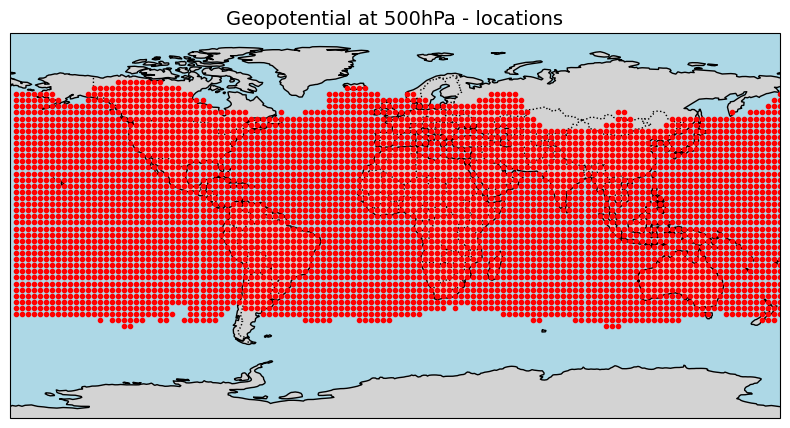

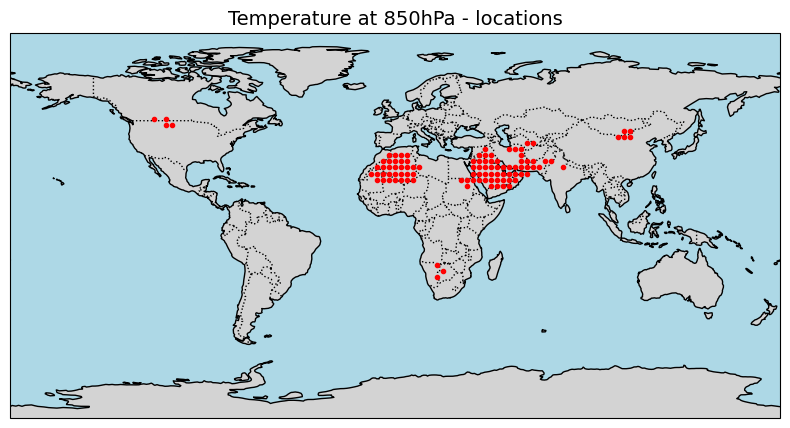

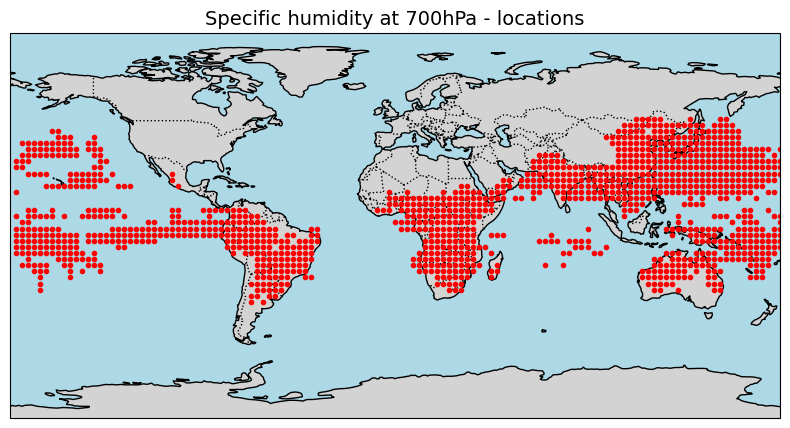

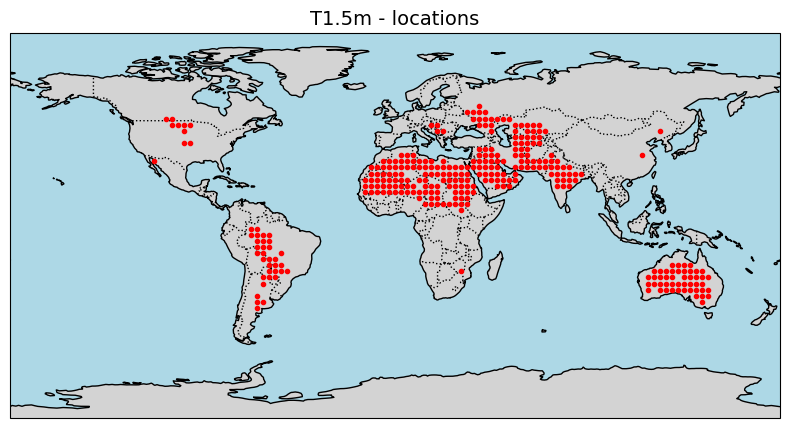

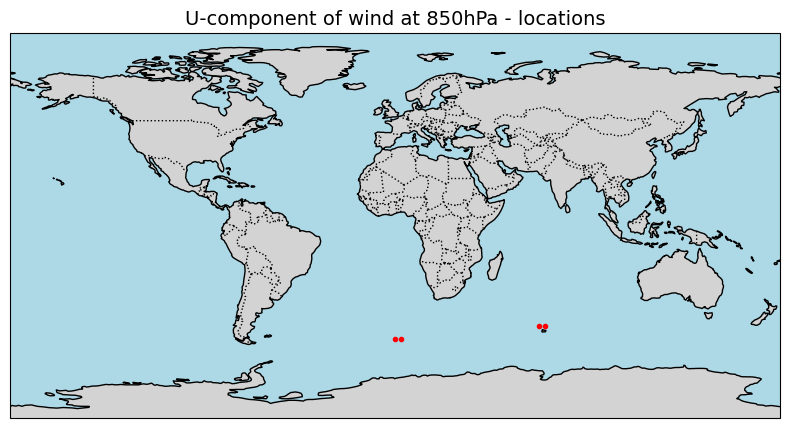

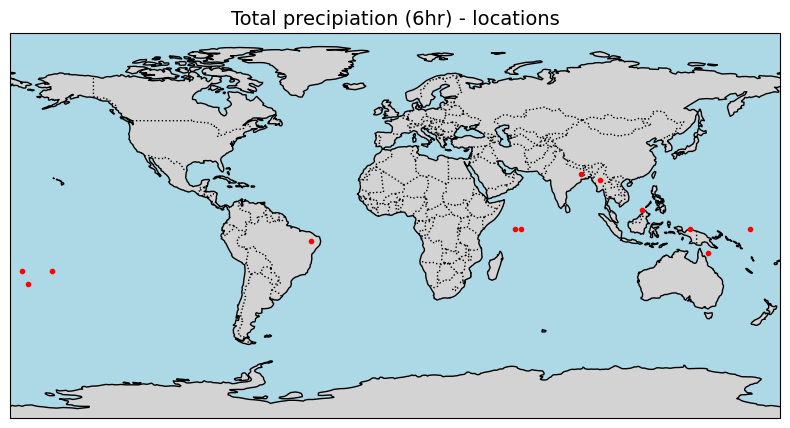

In [ ]:
for i in range(len(plot.KEY_VARIABLES_UKESM)):
    display_name, unit, variable, plevel = plot.KEY_VARIABLES_UKESM[i]
    if len(exceeding[i]['positive_list']) == 0:
        continue
    pos_df = pd.DataFrame(exceeding[i]['positive_list'])
    

    # get unique (lon, lat) pairs that ever had an exceedance
    unique_locs = pos_df[['lon', 'lat']].drop_duplicates().reset_index(drop=True)
    
    print(f"Unique exceedance locations: {len(unique_locs)}")
    print(unique_locs.head())
    
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.COASTLINE)
    
    for _, row in unique_locs.iterrows():
        ax.plot(
            row['lon'], row['lat'],
            marker='o', markersize=3,
            transform=ccrs.PlateCarree(),
            color='red'
        )
    
    ax.set_title(f'{display_name} - locations', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/plots/exceeding_locations/{variable}", dpi=400, bbox_inches='tight',)

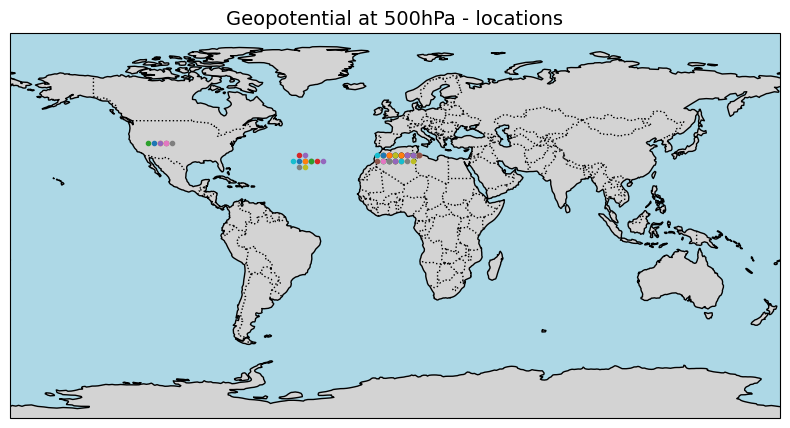

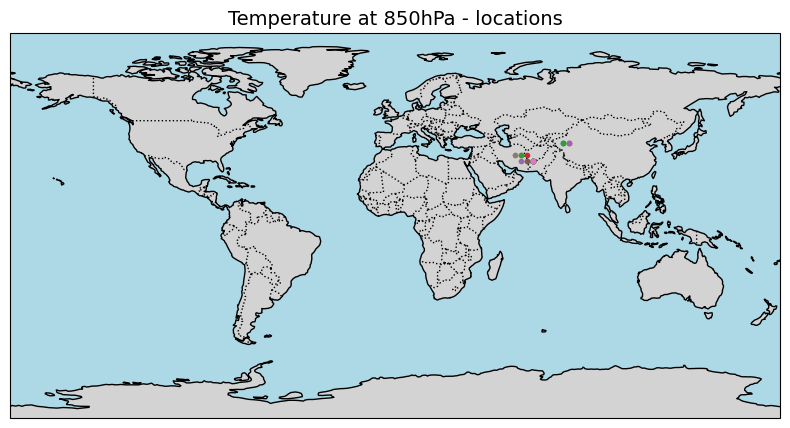

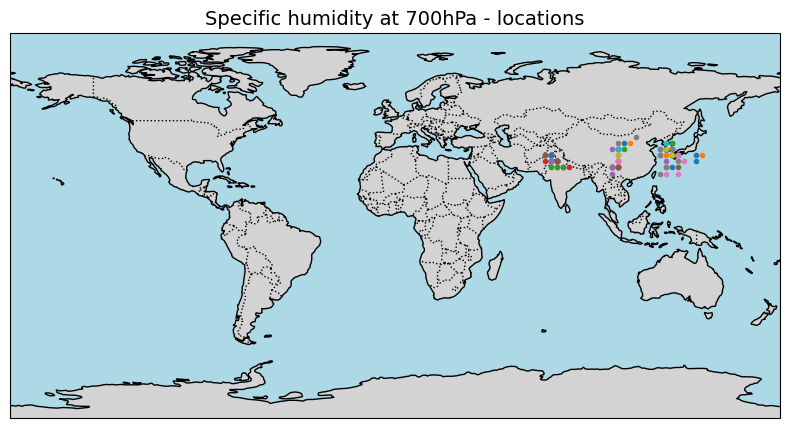

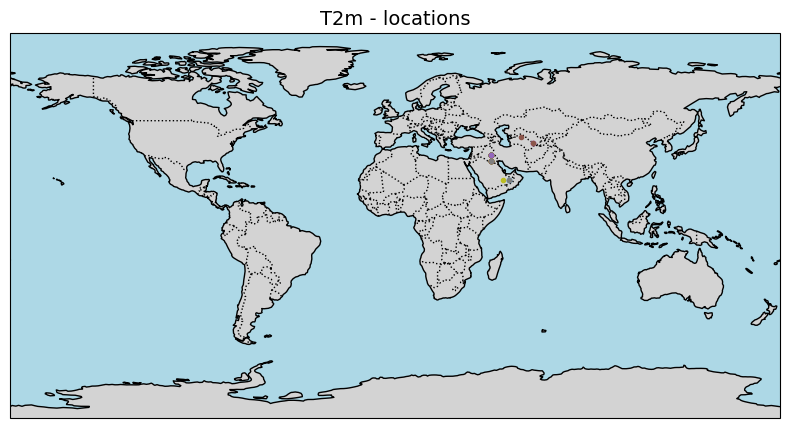

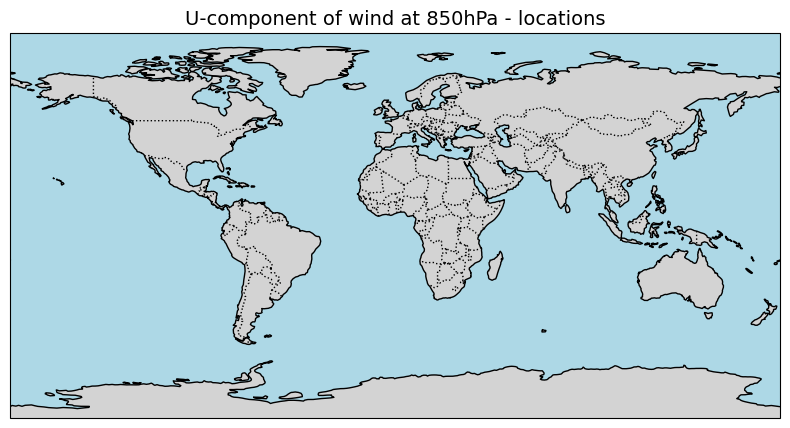

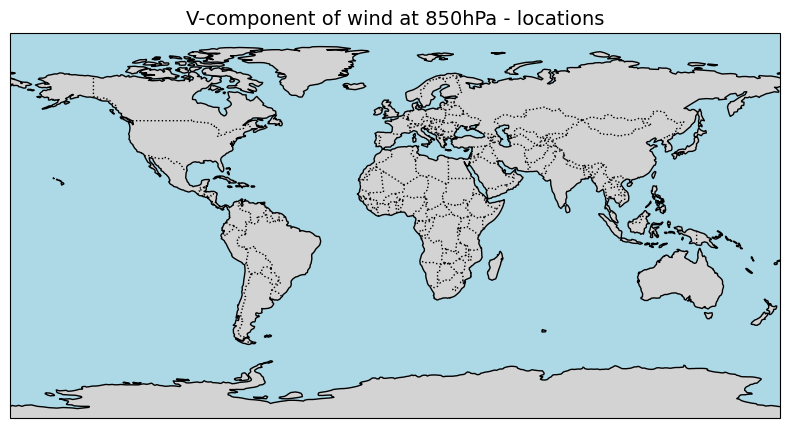

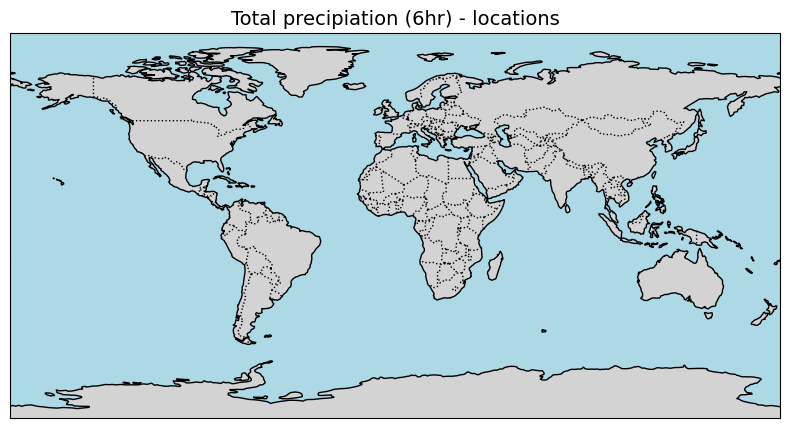

In [43]:
for i in range(len(plot.KEY_VARIABLES)):
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
    unique_locs = {}
    locs = [(x["lon"],x["lat"]) for x in exceeding[i]["positive_list"]]
    for (lon, lat) in locs:
        (slon, slat) = (str(lon), str(lat))
        if not slon in unique_locs.keys():
            unique_locs[slon]=slat
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()


    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.COASTLINE)

    for i, (lon,lat) in enumerate(locs):
        ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label=f'Location {i+1}')
        #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

    ax.set_title(f'{display_name} - locations', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/max_value_timelines/{variable}_locations_2046_2049", dpi=400, bbox_inches='tight',)
    